In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("key_stats.csv")

In [3]:
df.head()

,player_name,club,position,minutes_played,match_played,goals,assists,distance_covered
0,Courtois,Real Madrid,Goalkeeper,1230,13,0,0,64.2
1,Vinícius Júnior,Real Madrid,Forward,1199,13,4,6,133.0
2,Benzema,Real Madrid,Forward,1106,12,15,1,121.5
3,Modrić,Real Madrid,Midfielder,1077,13,0,4,124.5
4,Éder Militão,Real Madrid,Defender,1076,12,0,0,110.4


Separamos las columnas numéricas y las categóricas

In [4]:
numerical_columns = []
categorical_columns = []
for column in df.columns:
    if df[column].dtype == 'object':
        categorical_columns.append(column)
    else:
        numerical_columns.append(column)

Se aplica un preprocesamiento a los datos, estandarizando las columnas numéricas y aplicando one-hot encoding a las categóricas.

In [5]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_columns),
    ("cat", OneHotEncoder(), categorical_columns)
])

In [6]:
X = preprocessor.fit_transform(df)

Ejecutamos el algoritmo K-means para diferentes valores de k (número de clusters) y calculamos la inercia (SSE) para cada k.

In [7]:
inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    diff = inertias[-2] - inertias[-1] if k > 1 else 0
    print(f'K={k}, Inercia = {kmeans.inertia_:,.6f} - Diferencia = {diff:,.6f}')

K=1, Inercia = 5,720.895582 - Diferencia = 0.000000
K=2, Inercia = 4,190.306471 - Diferencia = 1,530.589112
K=3, Inercia = 3,604.986194 - Diferencia = 585.320277
K=4, Inercia = 3,283.383602 - Diferencia = 321.602592
K=5, Inercia = 3,063.809330 - Diferencia = 219.574273
K=6, Inercia = 2,935.800804 - Diferencia = 128.008525
K=7, Inercia = 2,818.679286 - Diferencia = 117.121518
K=8, Inercia = 2,712.766709 - Diferencia = 105.912577
K=9, Inercia = 2,629.383443 - Diferencia = 83.383266
K=10, Inercia = 2,547.029602 - Diferencia = 82.353841


Graficamos la inercia en función del número de clusters para identificar el "codo" que indica el número óptimo de clusters.

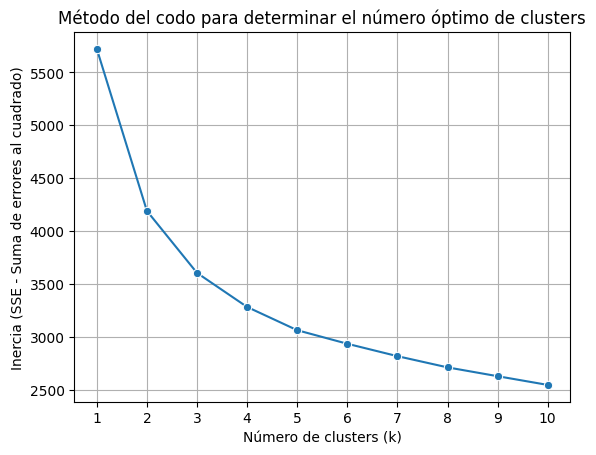

In [8]:
sns.lineplot(x=range(1, 11), y=inertias, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (SSE - Suma de errores al cuadrado)")
plt.title("Método del codo para determinar el número óptimo de clusters")
plt.xticks(range(1, 11))
plt.grid()
plt.show()

Elegimos el número óptimo de clusters basándonos en la gráfica del método del codo y ajustamos el modelo K-means con ese valor de k.

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)
df["Cluster"] = kmeans.labels_
df.head()

,player_name,club,position,minutes_played,match_played,goals,assists,distance_covered,Cluster
0,Courtois,Real Madrid,Goalkeeper,1230,13,0,0,64.2,0
1,Vinícius Júnior,Real Madrid,Forward,1199,13,4,6,133.0,2
2,Benzema,Real Madrid,Forward,1106,12,15,1,121.5,2
3,Modrić,Real Madrid,Midfielder,1077,13,0,4,124.5,2
4,Éder Militão,Real Madrid,Defender,1076,12,0,0,110.4,0


Visualización de los clusters usando PCA para reducir la dimensionalidad a 2D.

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

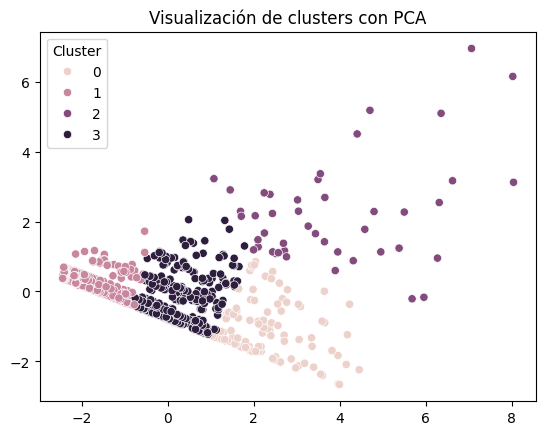

In [11]:
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["Cluster"])
plt.title("Visualización de clusters con PCA")
plt.show()

Analizamos los resultados del clustering.

In [12]:
df["Cluster"].value_counts()

Cluster
3    302
1    299
0    101
2     45
Name: count, dtype: int64

In [13]:
df[numerical_columns + ["Cluster"]].groupby("Cluster").mean()

,minutes_played,match_played,goals,assists,distance_covered
Cluster,,,,,
0,704.485149,8.910891,0.415842,0.534653,78.917822
1,101.702341,2.608696,0.080268,0.050167,12.076923
2,676.022222,8.955556,4.022222,2.466667,80.364444
3,383.215232,5.692053,0.400662,0.334437,44.079139


In [14]:
df[categorical_columns + ["Cluster"]].groupby("Cluster").agg(lambda x: x.mode()[0])

,player_name,club,position
Cluster,,,
0,Martínez,Liverpool,Defender
1,Diallo,Beşiktaş,Midfielder
2,Adeyemi,Man. City,Forward
3,Danilo,Atalanta,Midfielder


<Axes: xlabel='Cluster', ylabel='goals'>

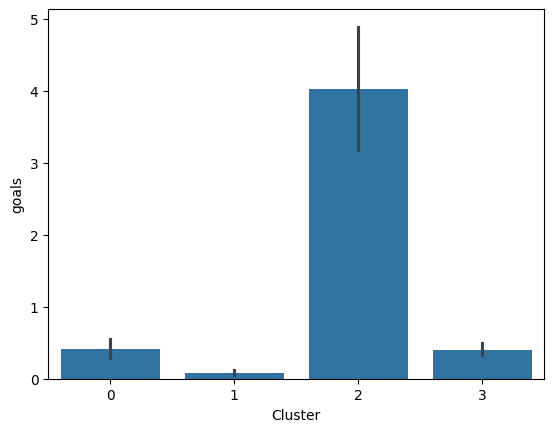

In [15]:
sns.barplot(df, x="Cluster", y="goals", estimator="mean")

<Axes: xlabel='goals', ylabel='minutes_played'>

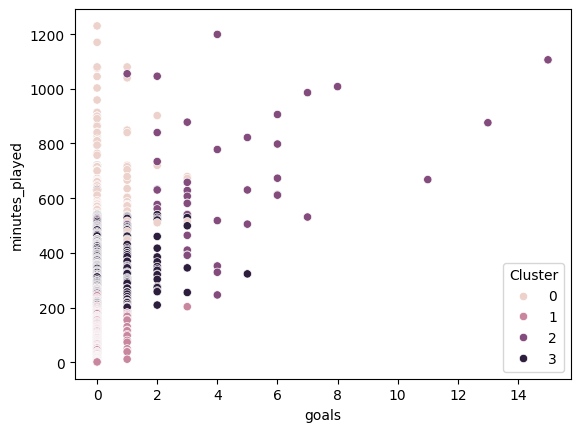

In [16]:
sns.scatterplot(df, x="goals", y="minutes_played", hue="Cluster")